# OncoBridge-MMCAT — Drug Response Fine-Tuning
## Data Processing & EDA · CCLE + GDSC2

### What this notebook does:
| Step | Description |
|------|-------------|
| 1 | Setup & paths |
| 2 | Load gene names JSON (from TCGA training) |
| 3 | Load & clean sanger IC50 labels |
| 4 | Load Model.csv — cell line metadata & ID mapping |
| 5 | Load & align CCLE mRNA — filter to TCGA gene space |
| 6 | Load & align CCLE CNV — filter to TCGA gene space |
| 7 | Load & align CCLE Mutation — filter to TCGA gene space |
| 8 | Load & align CCLE Methylation — filter to TCGA gene space |
| 9 | Master alignment — intersect all modalities + IC50 |
| 10 | EDA — label distribution, IC50 per drug, per cancer type |
| 11 | Apply scalers (same logic as TCGA training) |
| 12 | Train/Val/Test split at cell line level |
| 13 | Save processed arrays as parquet |

### Key design decisions (same as TCGA training):
- **mRNA:** StandardScaler (continuous log-expression)
- **CNV:** MaxAbsScaler (preserve 0 = normal copy number)
- **Mutation:** No scaling (binary 0/1/2)
- **Methylation:** No scaling (beta values already 0–1)
- **Gene filtering:** Exact same genes as TCGA training (from JSON) — no variance re-selection
- **Split:** At cell line level — never same cell line in train and test

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS & SETUP
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import gc
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.model_selection import train_test_split
from scipy import stats

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

# ── Helper functions (same style as TCGA notebook) ──────────────────────────
def section(title):
    print('\n' + '═'*70)
    print(f'  {title}')
    print('═'*70)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM: {mb:.1f} MB | shape: {df.shape}')

def missing_report(df, name):
    total     = df.size
    missing   = df.isnull().sum().sum()
    pct       = missing / total * 100
    print(f'  [{name}] Missing: {missing:,} / {total:,} ({pct:.2f}%)')

# ── FILE PATHS — update to your Kaggle input paths ──────────────────────────
BASE = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2'   # <-- update this to your dataset name

PATH_GENES    = f'{BASE}/selected_genes.json'
PATH_SANGER   = f'{BASE}/sanger-dose-response.csv'
PATH_MODEL    = f'{BASE}/Model.csv'
PATH_MRNA     = f'{BASE}/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv'
PATH_CNV      = f'{BASE}/OmicsCNGeneWGS.csv'
PATH_MUT      = f'{BASE}/OmicsSomaticMutationsMatrixDamaging.csv'
PATH_METH     = f'{BASE}/CCLE_RRBS_TSS_1kb_20180614.txt'

OUT_DIR = '/kaggle/working/'

# ── CONFIG ───────────────────────────────────────────────────────────────────
# Same scaler types as TCGA training — do NOT change
SCALER_TYPE = {
    'mrna': 'standard',   # continuous log-expression
    'cnv' : 'maxabs',     # ordinal, preserve 0
    'mut' : 'none',       # binary 0/1/2 — do NOT scale
    'meth': 'none',       # beta values [0,1] — do NOT scale
}

# Minimum samples per drug to include (avoid drugs with too few observations)
MIN_SAMPLES_PER_DRUG = 50

# Train/Val/Test split ratios (at cell line level)
VAL_SIZE  = 0.10
TEST_SIZE = 0.10
SEED      = 42

print('Setup complete.')
print(f'Scaler types: {SCALER_TYPE}')
print(f'Min samples per drug: {MIN_SAMPLES_PER_DRUG}')
print(f'Output directory: {OUT_DIR}')

Setup complete.
Scaler types: {'mrna': 'standard', 'cnv': 'maxabs', 'mut': 'none', 'meth': 'none'}
Min samples per drug: 50
Output directory: /kaggle/working/


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD TCGA GENE NAMES (the anchor of everything)
# ═══════════════════════════════════════════════════════════════════════════
section('2. TCGA SELECTED GENE NAMES — LOAD')

with open(PATH_GENES, 'r') as f:
    gene_names = json.load(f)

# These are the EXACT gene sets the model was trained on.
# CCLE data will be filtered down to these — no more, no less.
tcga_genes_mrna = gene_names['mrna']   # list of gene name strings
tcga_genes_cnv  = gene_names['cnv']
tcga_genes_mut  = gene_names['mut']
tcga_genes_meth = gene_names['meth']

print(f'Gene counts loaded from TCGA training:')
print(f'  mRNA:     {len(tcga_genes_mrna):,} genes')
print(f'  CNV:      {len(tcga_genes_cnv):,} genes')
print(f'  Mutation: {len(tcga_genes_mut):,} genes')
print(f'  Meth:     {len(tcga_genes_meth):,} genes')
print(f'  Total:    {len(tcga_genes_mrna)+len(tcga_genes_cnv)+len(tcga_genes_mut)+len(tcga_genes_meth):,} features')
print(f'\nFirst 5 mRNA genes: {tcga_genes_mrna[:5]}')
print(f'First 5 CNV genes:  {tcga_genes_cnv[:5]}')
print(f'First 5 Mut genes:  {tcga_genes_mut[:5]}')
print(f'First 5 Meth genes: {tcga_genes_meth[:5]}')


══════════════════════════════════════════════════════════════════════
  2. TCGA SELECTED GENE NAMES — LOAD
══════════════════════════════════════════════════════════════════════
Gene counts loaded from TCGA training:
  mRNA:     8,011 genes
  CNV:      3,500 genes
  Mutation: 2,500 genes
  Meth:     6,000 genes
  Total:    20,011 features

First 5 mRNA genes: ['KRT16', 'KRT14', 'KRT13', 'KRT6A', 'KRT6C']
First 5 CNV genes:  ['CSMD1', 'CDKN2A', 'CDKN2B', 'WHSC1L1', 'FGFR1']
First 5 Mut genes:  ['TP53', 'TTN', 'MUC16', 'CSMD3', 'PIK3CA']
First 5 Meth genes: ['CTSW', 'SAMSN1', 'ANKS4B', 'ALG1L', 'TYR']



══════════════════════════════════════════════════════════════════════
  3. SANGER GDSC2 — IC50 LABELS
══════════════════════════════════════════════════════════════════════
Loading sanger-dose-response.csv...
Raw sanger shape: (387626, 20)
Columns: ['DATASET', 'COSMIC_ID', 'DRUG_ID', 'MIN_CONC', 'MAX_CONC', 'RMSE_PUBLISHED', 'Z_SCORE_PUBLISHED', 'IC50_PUBLISHED', 'AUC_PUBLISHED', 'ARXSPAN_ID', 'DRUG_NAME', 'BROAD_ID', 'upper_limit', 'ec50', 'slope', 'lower_limit', 'auc', 'log2.ic50', 'mse', 'R2']

Unique COSMIC_IDs:  989
Unique drugs:       397
Unique DATASET:     ['GDSC1' 'GDSC2']

IC50 column (log2.ic50) stats:
count    99800.0000
mean         0.2346
std          3.6770
min        -13.3532
25%         -1.8183
50%          0.9717
75%          2.8118
max         11.9581

Filtered to GDSC2 only: 387,626 → 118,908 rows
Dropped missing IC50: 118,908 → 24,113 rows
Filtered drugs with <50 samples: 24,113 → 23,189 rows
Remaining unique drugs: 86

Top 15 drugs by sample count:
DRUG_NAME
FOR

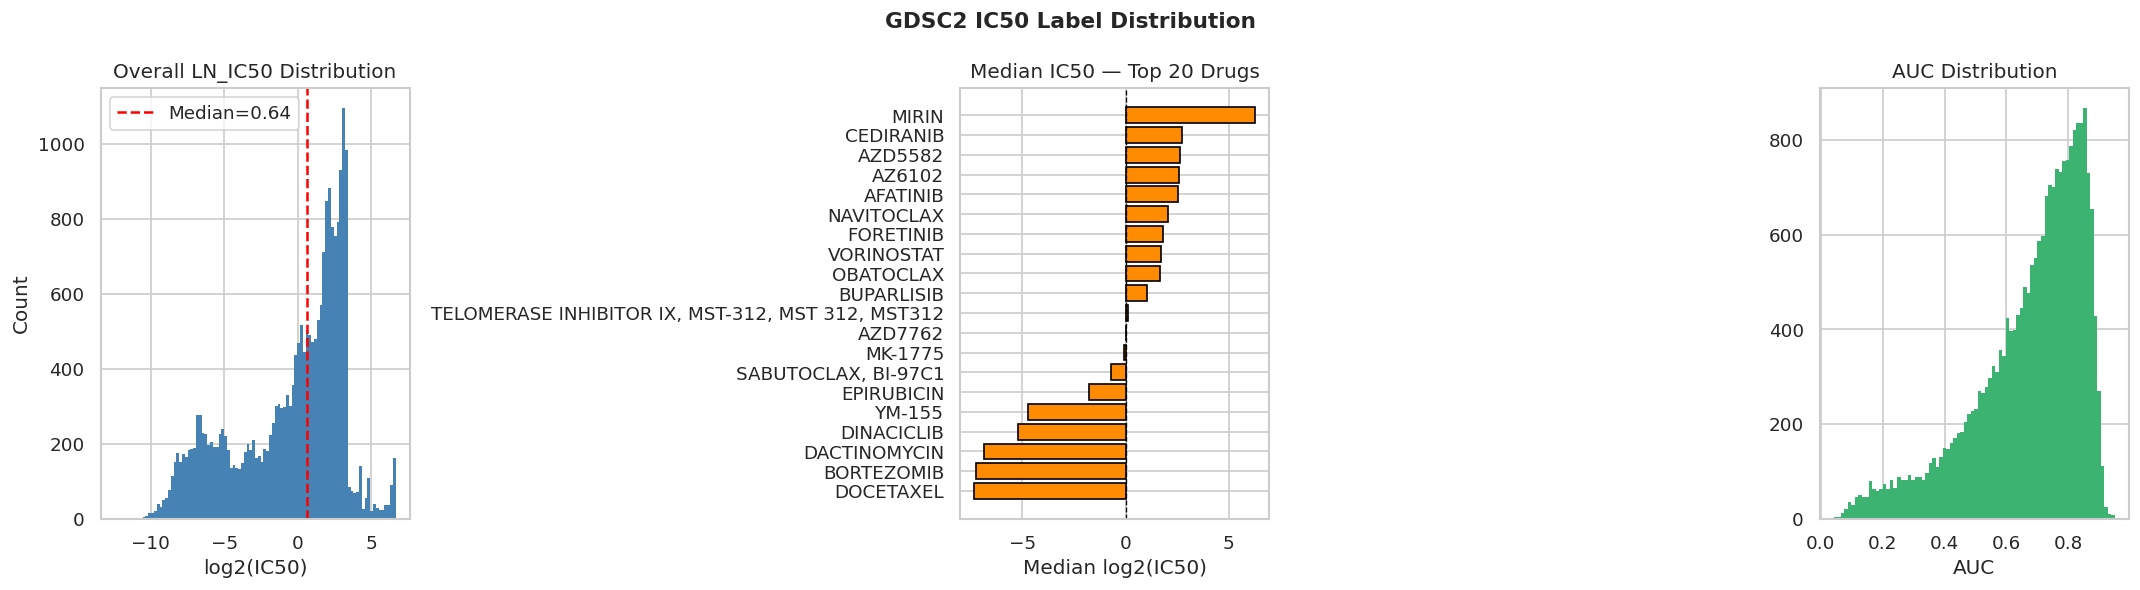


Final sanger shape: (23189, 6)
  [sanger] RAM: 2.5 MB | shape: (23189, 6)


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 3 — SANGER GDSC2 IC50 LABELS
# ═══════════════════════════════════════════════════════════════════════════
section('3. SANGER GDSC2 — IC50 LABELS')

print('Loading sanger-dose-response.csv...')
sanger = pd.read_csv(PATH_SANGER)
print(f'Raw sanger shape: {sanger.shape}')
print(f'Columns: {sanger.columns.tolist()}')

# ── Inspect key columns ────────────────────────────────────────────────────
print(f'\nUnique COSMIC_IDs:  {sanger["COSMIC_ID"].nunique():,}')
print(f'Unique drugs:       {sanger["DRUG_NAME"].nunique():,}')
print(f'Unique DATASET:     {sanger["DATASET"].unique()}')
print(f'\nIC50 column (log2.ic50) stats:')
print(sanger['log2.ic50'].describe().round(4).to_string())

# ── Use GDSC2 only (more recent, better quality than GDSC1) ────────────────
before = len(sanger)
sanger = sanger[sanger['DATASET'] == 'GDSC2'].copy()
print(f'\nFiltered to GDSC2 only: {before:,} → {len(sanger):,} rows')

# ── Drop rows with missing IC50 ────────────────────────────────────────────
before = len(sanger)
sanger = sanger.dropna(subset=['log2.ic50'])
print(f'Dropped missing IC50: {before:,} → {len(sanger):,} rows')

# ── Keep only needed columns ───────────────────────────────────────────────
sanger = sanger[['COSMIC_ID', 'DRUG_NAME', 'DRUG_ID',
                 'log2.ic50', 'AUC_PUBLISHED', 'Z_SCORE_PUBLISHED']].copy()
sanger = sanger.rename(columns={'log2.ic50': 'LN_IC50',
                                 'AUC_PUBLISHED': 'AUC',
                                 'Z_SCORE_PUBLISHED': 'Z_SCORE'})
sanger['COSMIC_ID'] = sanger['COSMIC_ID'].astype(int)

# ── Filter drugs with too few observations ─────────────────────────────────
drug_counts = sanger['DRUG_NAME'].value_counts()
valid_drugs = drug_counts[drug_counts >= MIN_SAMPLES_PER_DRUG].index
before = len(sanger)
sanger = sanger[sanger['DRUG_NAME'].isin(valid_drugs)]
print(f'Filtered drugs with <{MIN_SAMPLES_PER_DRUG} samples: {before:,} → {len(sanger):,} rows')
print(f'Remaining unique drugs: {sanger["DRUG_NAME"].nunique()}')

print(f'\nTop 15 drugs by sample count:')
print(sanger['DRUG_NAME'].value_counts().head(15).to_string())

# ── EDA — IC50 distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GDSC2 IC50 Label Distribution', fontsize=13, fontweight='bold')

axes[0].hist(sanger['LN_IC50'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Overall LN_IC50 Distribution')
axes[0].set_xlabel('log2(IC50)')
axes[0].set_ylabel('Count')
axes[0].axvline(sanger['LN_IC50'].median(), color='red', linestyle='--',
                label=f'Median={sanger["LN_IC50"].median():.2f}')
axes[0].legend()

top_drugs = sanger['DRUG_NAME'].value_counts().head(20).index
drug_medians = (sanger[sanger['DRUG_NAME'].isin(top_drugs)]
                .groupby('DRUG_NAME')['LN_IC50'].median()
                .sort_values())
axes[1].barh(drug_medians.index, drug_medians.values, color='darkorange', edgecolor='black')
axes[1].set_title('Median IC50 — Top 20 Drugs')
axes[1].set_xlabel('Median log2(IC50)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

axes[2].hist(sanger['AUC'], bins=80, color='mediumseagreen', edgecolor='none')
axes[2].set_title('AUC Distribution')
axes[2].set_xlabel('AUC')

plt.tight_layout()
plt.show()

print(f'\nFinal sanger shape: {sanger.shape}')
mem_usage(sanger, 'sanger')


══════════════════════════════════════════════════════════════════════
  4. MODEL.CSV — CELL LINE METADATA & ID MAPPING
══════════════════════════════════════════════════════════════════════
Loading Model.csv...
Model.csv shape: (2154, 49)
Columns: ['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures'] ...
Rows with valid COSMICID: 2,154 → 977

Unique ModelIDs:  977
Unique COSMICIDs: 977
Unique cancer types: 75

Joining sanger IC50 ← Model.csv on COSMIC_ID...
After join: 22,555 rows | 786 unique cell lines
Drugs covered: 86


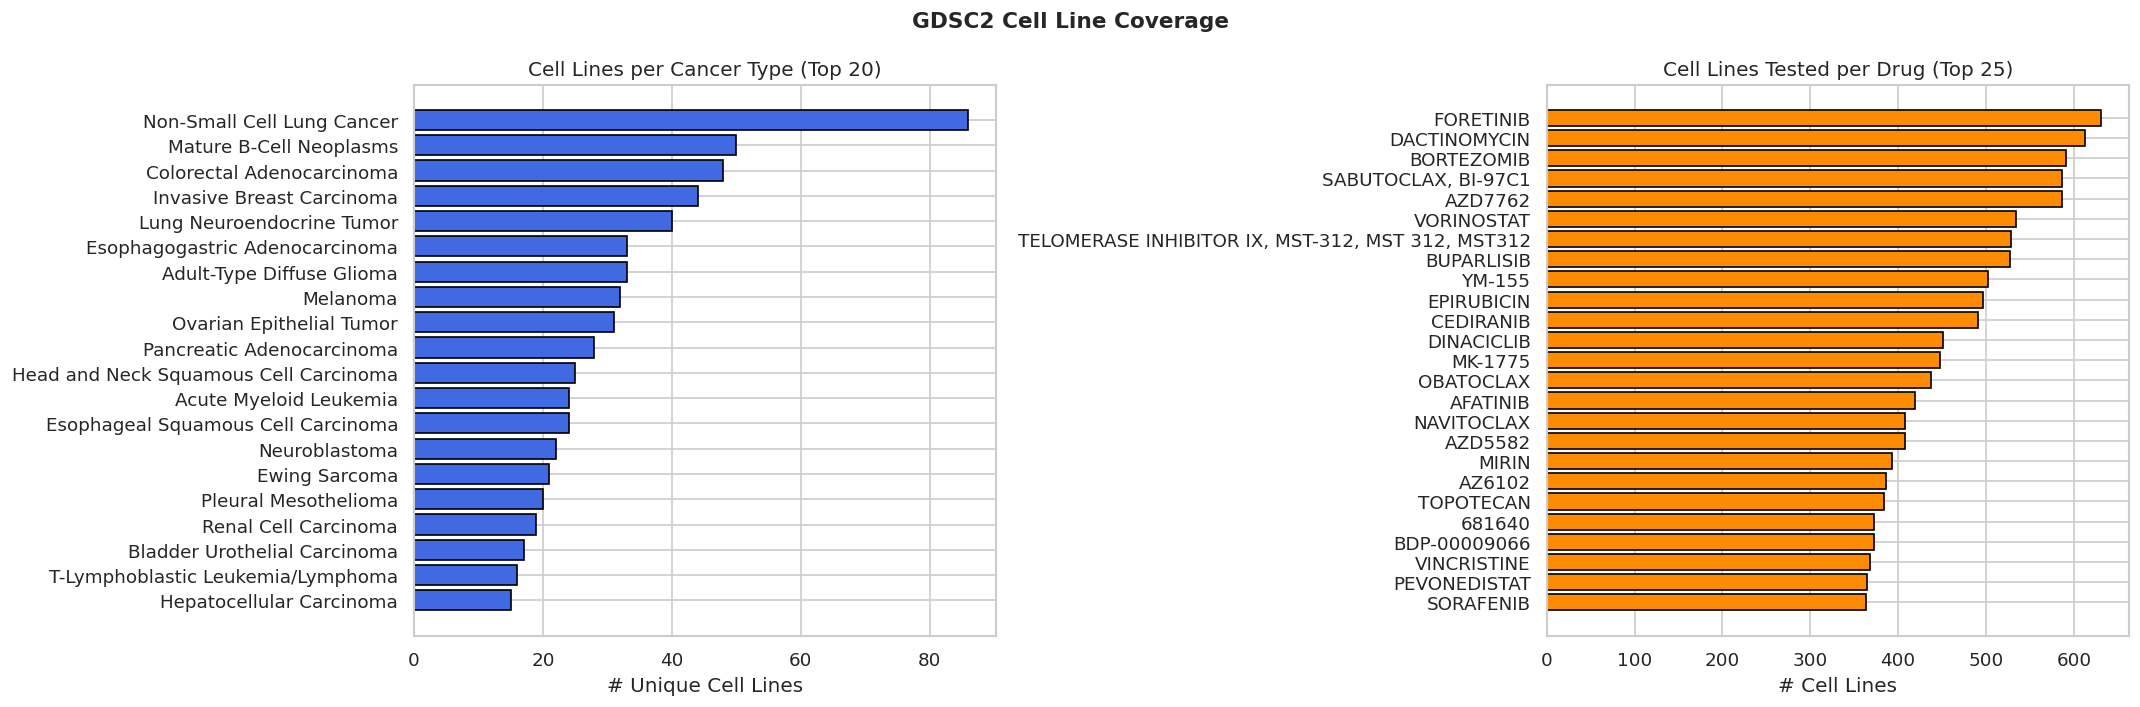


valid_model_ids (have IC50): 786


20203

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 4 — MODEL.CSV — CELL LINE ID MAPPING
# ═══════════════════════════════════════════════════════════════════════════
section('4. MODEL.CSV — CELL LINE METADATA & ID MAPPING')

print('Loading Model.csv...')
model_df = pd.read_csv(PATH_MODEL)
print(f'Model.csv shape: {model_df.shape}')
print(f'Columns: {model_df.columns.tolist()[:10]} ...')

# ── Keep only what we need ─────────────────────────────────────────────────
model_df = model_df[['ModelID', 'CellLineName', 'StrippedCellLineName',
                     'COSMICID', 'OncotreePrimaryDisease', 'OncotreeLineage',
                     'OncotreeSubtype']].copy()

# ── Drop rows with no COSMIC_ID (can't join to sanger) ────────────────────
before = len(model_df)
model_df = model_df.dropna(subset=['COSMICID'])
model_df['COSMICID'] = model_df['COSMICID'].astype(int)
print(f'Rows with valid COSMICID: {before:,} → {len(model_df):,}')

print(f'\nUnique ModelIDs:  {model_df["ModelID"].nunique():,}')
print(f'Unique COSMICIDs: {model_df["COSMICID"].nunique():,}')
print(f'Unique cancer types: {model_df["OncotreePrimaryDisease"].nunique()}')

# ── Join sanger + model_df on COSMIC_ID ───────────────────────────────────
print('\nJoining sanger IC50 ← Model.csv on COSMIC_ID...')
ic50_df = sanger.merge(model_df, left_on='COSMIC_ID', right_on='COSMICID', how='inner')
print(f'After join: {len(ic50_df):,} rows | {ic50_df["ModelID"].nunique():,} unique cell lines')
print(f'Drugs covered: {ic50_df["DRUG_NAME"].nunique()}')

# ── EDA — cancer type distribution in GDSC2 ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('GDSC2 Cell Line Coverage', fontsize=13, fontweight='bold')

ct_counts = ic50_df.groupby('OncotreePrimaryDisease')['ModelID'].nunique().sort_values(ascending=False).head(20)
axes[0].barh(ct_counts.index, ct_counts.values, color='royalblue', edgecolor='black')
axes[0].set_title('Cell Lines per Cancer Type (Top 20)')
axes[0].set_xlabel('# Unique Cell Lines')
axes[0].invert_yaxis()

drug_cl_counts = ic50_df.groupby('DRUG_NAME')['ModelID'].nunique().sort_values(ascending=False).head(25)
axes[1].barh(drug_cl_counts.index, drug_cl_counts.values, color='darkorange', edgecolor='black')
axes[1].set_title('Cell Lines Tested per Drug (Top 25)')
axes[1].set_xlabel('# Cell Lines')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

valid_model_ids = set(ic50_df['ModelID'].unique())
print(f'\nvalid_model_ids (have IC50): {len(valid_model_ids):,}')
del sanger, model_df
gc.collect()


══════════════════════════════════════════════════════════════════════
  5. CCLE mRNA — LOAD, CLEAN & FILTER TO TCGA GENE SPACE
══════════════════════════════════════════════════════════════════════
Loading OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv...
(This file has ProfileID, is_default_entry, ModelID as first 3 columns)
Raw shape: (1775, 19220)
First 5 columns: ['SequencingID', 'ModelConditionID', 'ModelID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel']
After keeping default profiles: 1,775 → 1,719 rows
Gene columns available: 19,215
After gene name cleaning: 19,215 unique genes
Example gene names: ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM']

Filtered to cell lines with IC50: 1,719 → 609

Gene space alignment (mRNA):
  TCGA selected genes:      8,011
  CCLE available genes:     19,215
  Overlap:                  7,374
  Missing in CCLE (→ 0):   637 (8.0%)

Final mRNA shape: (609, 8011)  (rows=cell lines, cols=8011 TCGA genes)
  [mRNA] Missing: 0 / 4,878,699 (0.00%)


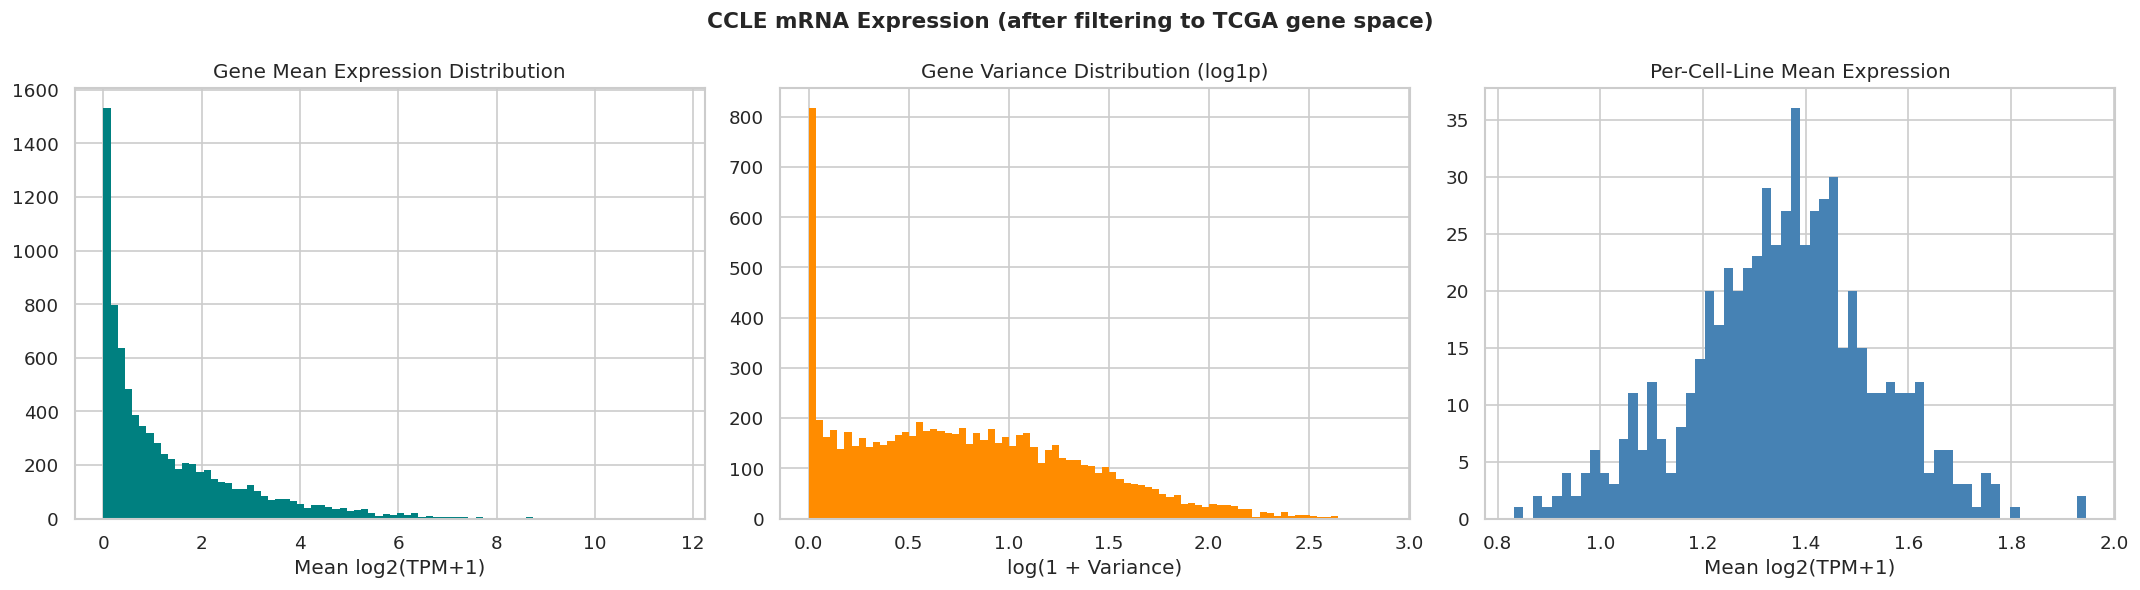

  [mRNA filtered] RAM: 19.6 MB | shape: (609, 8011)

Cell lines with mRNA: 609


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 5 — CCLE mRNA EXPRESSION
# ═══════════════════════════════════════════════════════════════════════════
section('5. CCLE mRNA — LOAD, CLEAN & FILTER TO TCGA GENE SPACE')

print('Loading OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv...')
print('(This file has ProfileID, is_default_entry, ModelID as first 3 columns)')
mrna_raw = pd.read_csv(PATH_MRNA, index_col=0)  # first unnamed col as index
print(f'Raw shape: {mrna_raw.shape}')
print(f'First 5 columns: {mrna_raw.columns.tolist()[:5]}')

# Keep only default profiles — values are "Yes"/"No" strings
before = len(mrna_raw)
mrna_raw = mrna_raw[mrna_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
print(f'After keeping default profiles: {before:,} → {len(mrna_raw):,} rows')

# Set ModelID as index
mrna_raw = mrna_raw.set_index('ModelID')
mrna_raw = mrna_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                   'IsDefaultEntryForMC', 'IsDefaultEntryForModel'], 
                          errors='ignore')
print(f'Gene columns available: {mrna_raw.shape[1]:,}')

# ── Clean gene column names (remove Entrez ID suffix if present) ─────────
# DepMap format: "BRCA1 (672)" — extract just the gene symbol
mrna_raw.columns = [str(c).split(' (')[0].strip() for c in mrna_raw.columns]
mrna_raw = mrna_raw.loc[:, ~mrna_raw.columns.duplicated(keep='first')]
print(f'After gene name cleaning: {mrna_raw.shape[1]:,} unique genes')
print(f'Example gene names: {mrna_raw.columns.tolist()[:5]}')

# ── Filter to only cell lines with IC50 data ──────────────────────────────
before = len(mrna_raw)
mrna_raw = mrna_raw[mrna_raw.index.isin(valid_model_ids)]
print(f'\nFiltered to cell lines with IC50: {before:,} → {len(mrna_raw):,}')

# ── Filter to TCGA gene space ──────────────────────────────────────────────
# Find overlap between CCLE genes and TCGA selected genes
ccle_genes = set(mrna_raw.columns)
tcga_genes_set = set(tcga_genes_mrna)
overlap = ccle_genes & tcga_genes_set
missing_in_ccle = tcga_genes_set - ccle_genes

print(f'\nGene space alignment (mRNA):')
print(f'  TCGA selected genes:      {len(tcga_genes_mrna):,}')
print(f'  CCLE available genes:     {len(ccle_genes):,}')
print(f'  Overlap:                  {len(overlap):,}')
print(f'  Missing in CCLE (→ 0):   {len(missing_in_ccle):,} ({len(missing_in_ccle)/len(tcga_genes_mrna)*100:.1f}%)')

# Reindex to EXACT TCGA gene list — missing genes filled with 0
mrna_df = mrna_raw.reindex(columns=tcga_genes_mrna, fill_value=0.0).astype(np.float32)
print(f'\nFinal mRNA shape: {mrna_df.shape}  (rows=cell lines, cols={len(tcga_genes_mrna)} TCGA genes)')

# ── Missing value check ────────────────────────────────────────────────────
missing_report(mrna_df, 'mRNA')
# Fill any remaining NaN with 0 (missing gene → no expression)
mrna_df = mrna_df.fillna(0.0)

# ── EDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE mRNA Expression (after filtering to TCGA gene space)', fontsize=13, fontweight='bold')

gene_means = mrna_df.mean(axis=0)
gene_vars  = mrna_df.var(axis=0)
sample_means = mrna_df.mean(axis=1)

axes[0].hist(gene_means, bins=80, color='teal', edgecolor='none')
axes[0].set_title('Gene Mean Expression Distribution')
axes[0].set_xlabel('Mean log2(TPM+1)')

axes[1].hist(np.log1p(gene_vars), bins=80, color='darkorange', edgecolor='none')
axes[1].set_title('Gene Variance Distribution (log1p)')
axes[1].set_xlabel('log(1 + Variance)')

axes[2].hist(sample_means, bins=60, color='steelblue', edgecolor='none')
axes[2].set_title('Per-Cell-Line Mean Expression')
axes[2].set_xlabel('Mean log2(TPM+1)')

plt.tight_layout()
plt.show()

valid_model_ids_mrna = set(mrna_df.index)
mem_usage(mrna_df, 'mRNA filtered')
del mrna_raw, gene_means, gene_vars, sample_means
gc.collect()
print(f'\nCell lines with mRNA: {len(valid_model_ids_mrna):,}')


══════════════════════════════════════════════════════════════════════
  6. CCLE CNV — LOAD, CLEAN & FILTER TO TCGA GENE SPACE
══════════════════════════════════════════════════════════════════════
Loading OmicsCNGeneWGS.csv...
(WGS-based gene-level copy number — linear scale)
Raw shape: (1132, 19960)
After keeping default profiles: 1,118 rows
Filtered to cell lines with IC50: 1,118 → 440
Missing values before fill: 356,840
Applied log2(CN/2) transform — diploid=0, del<0, amp>0

Gene space alignment (CNV):
  TCGA selected genes:    3,500
  CCLE available genes:   19,955
  Overlap:                3,232
  Missing in CCLE (→ 0): 268 (7.7%)

Final CNV shape: (440, 3500)


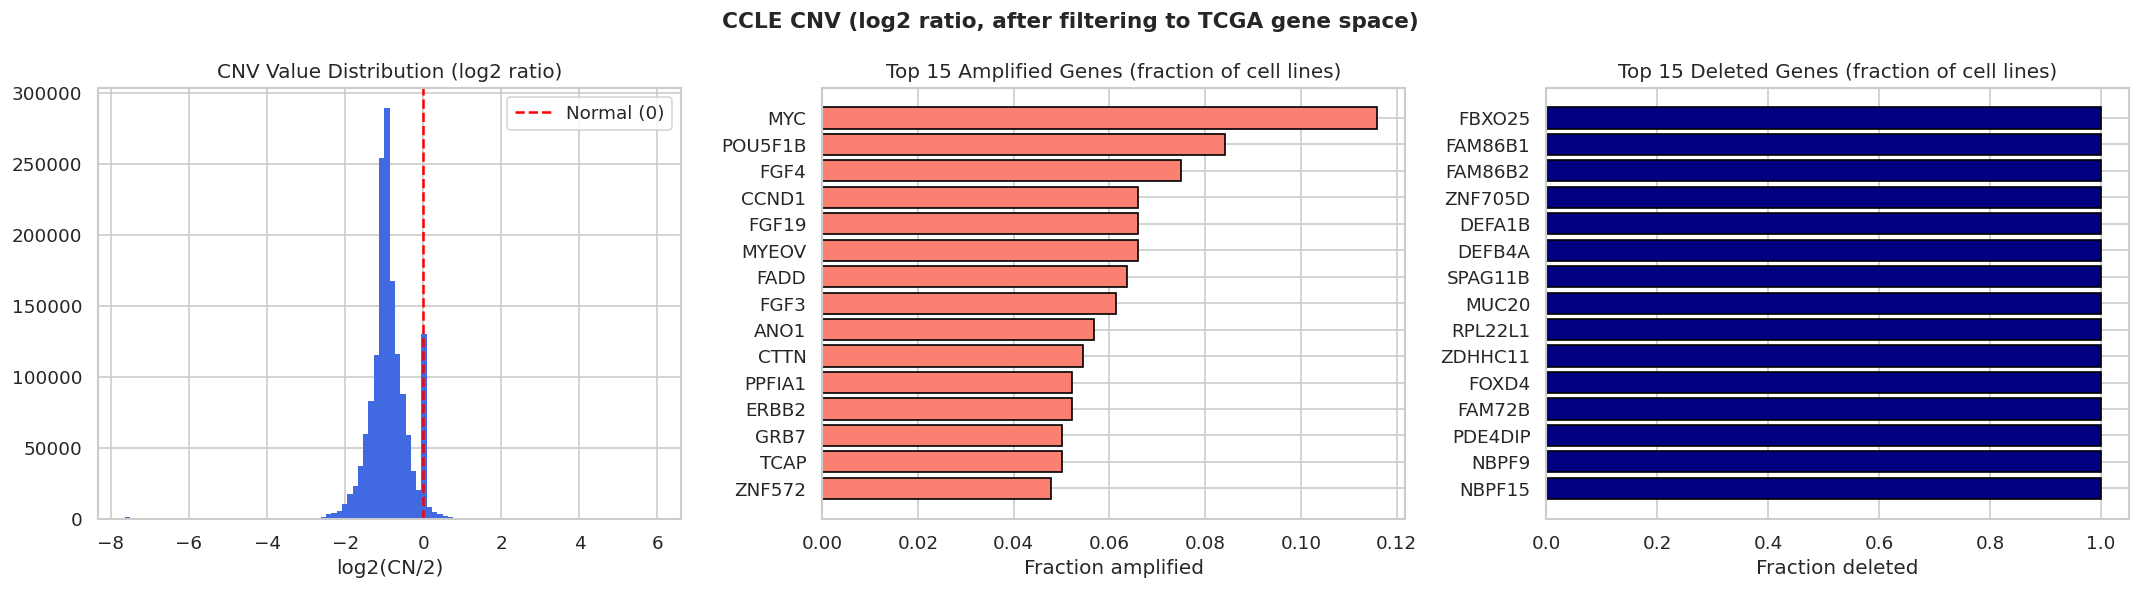

  [CNV filtered] RAM: 6.2 MB | shape: (440, 3500)

Cell lines with CNV: 440


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 6 — CCLE CNV (COPY NUMBER)
# ═══════════════════════════════════════════════════════════════════════════
section('6. CCLE CNV — LOAD, CLEAN & FILTER TO TCGA GENE SPACE')

print('Loading OmicsCNGeneWGS.csv...')
print('(WGS-based gene-level copy number — linear scale)')
cnv_raw = pd.read_csv(PATH_CNV, index_col=0)
print(f'Raw shape: {cnv_raw.shape}')
cnv_raw = cnv_raw[cnv_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
cnv_raw = cnv_raw.set_index('ModelID')
cnv_raw = cnv_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                  'IsDefaultEntryForMC', 'IsDefaultEntryForModel'],
                         errors='ignore')
print(f'After keeping default profiles: {len(cnv_raw):,} rows')
# ── Clean gene column names ────────────────────────────────────────────────
cnv_raw.columns = [str(c).split(' (')[0].strip() for c in cnv_raw.columns]
cnv_raw = cnv_raw.loc[:, ~cnv_raw.columns.duplicated(keep='first')]

# ── Filter to cell lines with IC50 data ───────────────────────────────────
before = len(cnv_raw)
cnv_raw = cnv_raw[cnv_raw.index.isin(valid_model_ids)]
print(f'Filtered to cell lines with IC50: {before:,} → {len(cnv_raw):,}')

# ── Missing value handling ─────────────────────────────────────────────────
# OmicsCNGeneWGS is linear scale (not thresholded like TCGA)
# Missing = assume normal copy number = 1.0 (linear) → log2(1) = 0
nan_count = cnv_raw.isnull().sum().sum()
print(f'Missing values before fill: {nan_count:,}')
cnv_raw = cnv_raw.fillna(1.0)   # 1.0 = normal diploid in linear scale

# ── Log2 transform to match TCGA format ───────────────────────────────────
# TCGA CNV was GISTIC2 thresholded (-2,-1,0,+1,+2)
# CCLE WGS CNV is linear → convert to log2 ratio for similar scale
# log2(CN/2) gives 0 for diploid, negative for deletion, positive for amplification
# Clip at small positive to avoid log(0)
cnv_raw = cnv_raw.clip(lower=0.01)
cnv_raw = np.log2(cnv_raw / 2.0).astype(np.float32)
print('Applied log2(CN/2) transform — diploid=0, del<0, amp>0')

# ── Filter to TCGA gene space ──────────────────────────────────────────────
ccle_genes = set(cnv_raw.columns)
tcga_genes_set = set(tcga_genes_cnv)
overlap = ccle_genes & tcga_genes_set
missing_in_ccle = tcga_genes_set - ccle_genes

print(f'\nGene space alignment (CNV):')
print(f'  TCGA selected genes:    {len(tcga_genes_cnv):,}')
print(f'  CCLE available genes:   {len(ccle_genes):,}')
print(f'  Overlap:                {len(overlap):,}')
print(f'  Missing in CCLE (→ 0): {len(missing_in_ccle):,} ({len(missing_in_ccle)/len(tcga_genes_cnv)*100:.1f}%)')

cnv_df = cnv_raw.reindex(columns=tcga_genes_cnv, fill_value=0.0).astype(np.float32)
print(f'\nFinal CNV shape: {cnv_df.shape}')

# ── EDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE CNV (log2 ratio, after filtering to TCGA gene space)', fontsize=13, fontweight='bold')

# Flatten a sample for distribution plot
flat_sample = cnv_df.values.flatten()
flat_sample = flat_sample[np.abs(flat_sample) < 10]   # remove extreme outliers for viz

axes[0].hist(flat_sample, bins=100, color='royalblue', edgecolor='none')
axes[0].set_title('CNV Value Distribution (log2 ratio)')
axes[0].set_xlabel('log2(CN/2)')
axes[0].axvline(0, color='red', linestyle='--', label='Normal (0)')
axes[0].legend()

amp_rate = (cnv_df > 0.5).mean(axis=0)   # fraction of cell lines with amplification
del_rate = (cnv_df < -0.5).mean(axis=0)  # fraction of cell lines with deletion

top_amp = amp_rate.nlargest(15)
axes[1].barh(top_amp.index, top_amp.values, color='salmon', edgecolor='black')
axes[1].set_title('Top 15 Amplified Genes (fraction of cell lines)')
axes[1].set_xlabel('Fraction amplified')
axes[1].invert_yaxis()

top_del = del_rate.nlargest(15)
axes[2].barh(top_del.index, top_del.values, color='navy', edgecolor='black')
axes[2].set_title('Top 15 Deleted Genes (fraction of cell lines)')
axes[2].set_xlabel('Fraction deleted')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

valid_model_ids_cnv = set(cnv_df.index)
mem_usage(cnv_df, 'CNV filtered')
del cnv_raw, flat_sample, amp_rate, del_rate
gc.collect()
print(f'\nCell lines with CNV: {len(valid_model_ids_cnv):,}')


══════════════════════════════════════════════════════════════════════
  7. CCLE MUTATION — LOAD, CLEAN & FILTER TO TCGA GENE SPACE
══════════════════════════════════════════════════════════════════════
Loading OmicsSomaticMutationsMatrixDamaging.csv...
(Binary matrix: 0=wildtype, 1/2=damaging mutation)
Raw shape: (3044, 19583)
After keeping default profiles: 1,968 rows
Filtered to cell lines with IC50: 1,968 → 776
Missing values: 0 → filling with 0 (wildtype)
Unique values in mutation matrix: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
Sparsity (fraction zeros): 99.6%
Clipped to binary 0/1 — same as TCGA mutation format

Gene space alignment (Mutation):
  TCGA selected genes:    2,500
  CCLE available genes:   19,578
  Overlap:                2,380
  Missing in CCLE (→ 0): 120 (4.8%)

Final Mutation shape: (776, 2500)


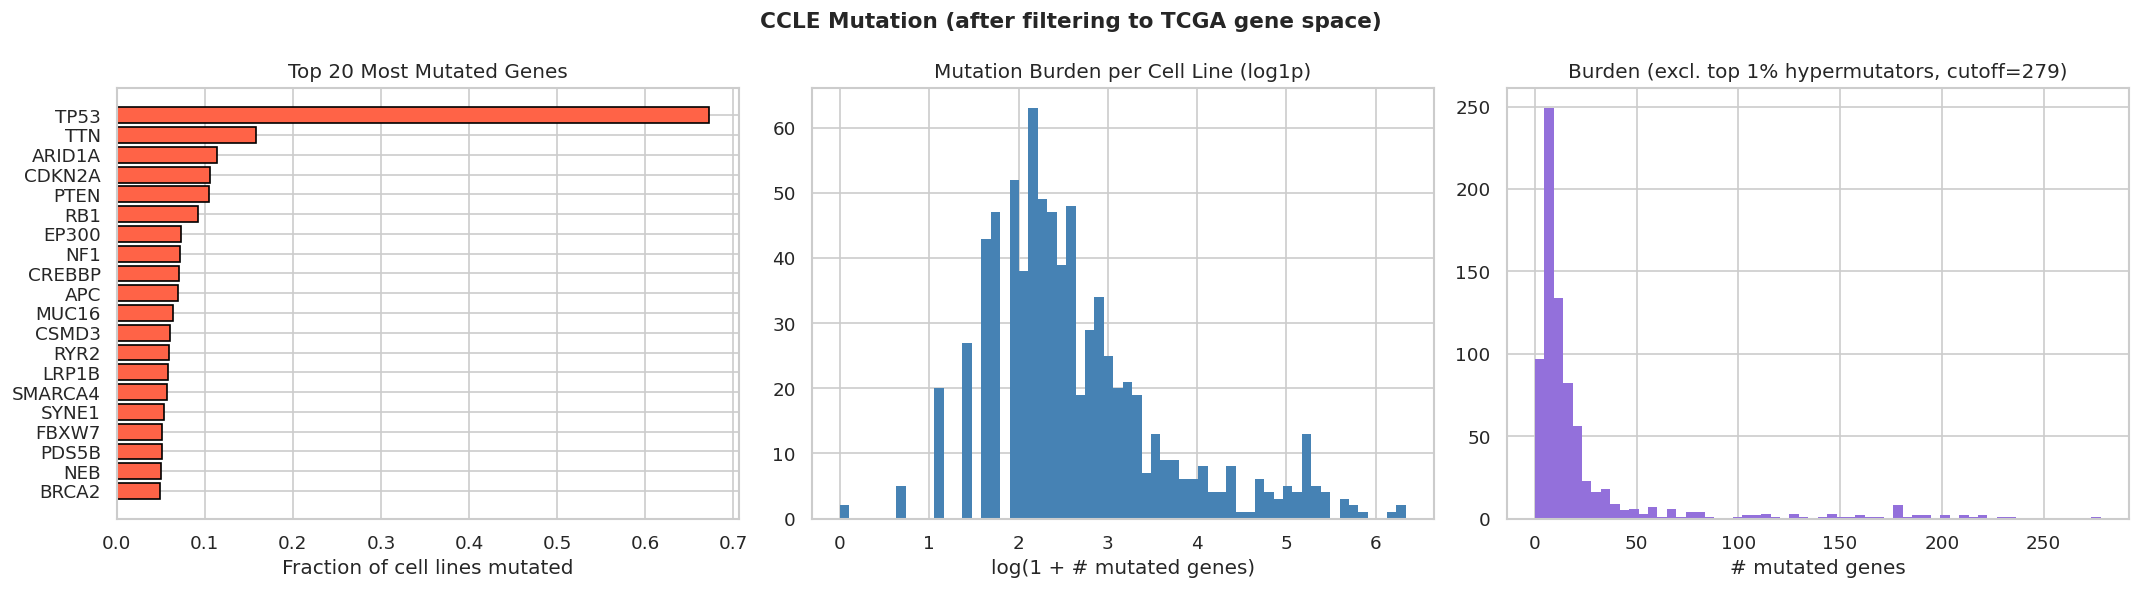

  [Mutation filtered] RAM: 2.0 MB | shape: (776, 2500)

Cell lines with Mutation: 776


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 7 — CCLE MUTATION
# ═══════════════════════════════════════════════════════════════════════════
section('7. CCLE MUTATION — LOAD, CLEAN & FILTER TO TCGA GENE SPACE')

print('Loading OmicsSomaticMutationsMatrixDamaging.csv...')
print('(Binary matrix: 0=wildtype, 1/2=damaging mutation)')
mut_raw = pd.read_csv(PATH_MUT, index_col=0)
print(f'Raw shape: {mut_raw.shape}')
mut_raw = mut_raw[mut_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
mut_raw = mut_raw.set_index('ModelID')
mut_raw = mut_raw.drop(columns=['SequencingID', 'ModelConditionID',
                                  'IsDefaultEntryForMC', 'IsDefaultEntryForModel'],
                         errors='ignore')
print(f'After keeping default profiles: {len(mut_raw):,} rows')

# ── Clean gene names ───────────────────────────────────────────────────────
mut_raw.columns = [str(c).split(' (')[0].strip() for c in mut_raw.columns]
mut_raw = mut_raw.loc[:, ~mut_raw.columns.duplicated(keep='first')]

# ── Filter to cell lines with IC50 ────────────────────────────────────────
before = len(mut_raw)
mut_raw = mut_raw[mut_raw.index.isin(valid_model_ids)]
print(f'Filtered to cell lines with IC50: {before:,} → {len(mut_raw):,}')

# ── Missing value handling ─────────────────────────────────────────────────
# Missing mutation = wildtype (not mutated) = 0
nan_count = mut_raw.isnull().sum().sum()
print(f'Missing values: {nan_count:,} → filling with 0 (wildtype)')
mut_raw = mut_raw.fillna(0)

# ── Check value range ─────────────────────────────────────────────────────
unique_vals = sorted(mut_raw.stack().unique())
print(f'Unique values in mutation matrix: {unique_vals[:10]}')
sparsity = (mut_raw == 0).mean().mean()
print(f'Sparsity (fraction zeros): {sparsity*100:.1f}%')

# Clip to 0/1 — values >1 (allele frequency sums) treated as mutated=1
mut_raw = mut_raw.clip(0, 1).round(0).astype(np.int8)
print('Clipped to binary 0/1 — same as TCGA mutation format')

# ── Filter to TCGA gene space ──────────────────────────────────────────────
ccle_genes = set(mut_raw.columns)
tcga_genes_set = set(tcga_genes_mut)
overlap = ccle_genes & tcga_genes_set
missing_in_ccle = tcga_genes_set - ccle_genes

print(f'\nGene space alignment (Mutation):')
print(f'  TCGA selected genes:    {len(tcga_genes_mut):,}')
print(f'  CCLE available genes:   {len(ccle_genes):,}')
print(f'  Overlap:                {len(overlap):,}')
print(f'  Missing in CCLE (→ 0): {len(missing_in_ccle):,} ({len(missing_in_ccle)/len(tcga_genes_mut)*100:.1f}%)')

mut_df = mut_raw.reindex(columns=tcga_genes_mut, fill_value=0).astype(np.int8)
print(f'\nFinal Mutation shape: {mut_df.shape}')

# ── EDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE Mutation (after filtering to TCGA gene space)', fontsize=13, fontweight='bold')

mut_rate = mut_df.mean(axis=0)
sample_burden = mut_df.sum(axis=1)

top20 = mut_rate.nlargest(20)
axes[0].barh(top20.index, top20.values, color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Most Mutated Genes')
axes[0].set_xlabel('Fraction of cell lines mutated')
axes[0].invert_yaxis()

axes[1].hist(np.log1p(sample_burden), bins=60, color='steelblue', edgecolor='none')
axes[1].set_title('Mutation Burden per Cell Line (log1p)')
axes[1].set_xlabel('log(1 + # mutated genes)')

q99 = sample_burden.quantile(0.99)
axes[2].hist(sample_burden[sample_burden <= q99], bins=60,
             color='mediumpurple', edgecolor='none')
axes[2].set_title(f'Burden (excl. top 1% hypermutators, cutoff={q99:.0f})')
axes[2].set_xlabel('# mutated genes')

plt.tight_layout()
plt.show()

valid_model_ids_mut = set(mut_df.index)
mem_usage(mut_df, 'Mutation filtered')
del mut_raw, mut_rate, sample_burden
gc.collect()
print(f'\nCell lines with Mutation: {len(valid_model_ids_mut):,}')


══════════════════════════════════════════════════════════════════════
  8. CCLE METHYLATION — LOAD, CLEAN & FILTER TO TCGA GENE SPACE
══════════════════════════════════════════════════════════════════════
Loading CCLE_RRBS_TSS_1kb_20180614.txt...
Format: rows=TSS regions, cols=metadata + cell lines
Values: methylation beta values (0=unmethylated, 1=fully methylated)
Raw shape (rows=TSS regions, cols=metadata+cell lines): (20192, 849)
First 7 columns: ['gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage', 'DMS53_LUNG']
After dropping metadata: (20192, 843) (rows=TSS regions, cols=cell lines)
Example cell line names: ['DMS53_LUNG', 'SW1116_LARGE_INTESTINE', 'P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'UMUC3_URINARY_TRACT']
Gene aggregation (mean per gene): 20,192 TSS → 16,494 unique genes
After transpose: (843, 16494) (rows=cell lines, cols=genes)
Example cell line names: ['DMS53_LUNG', 'SW1116_LARGE_INTESTINE', 'P3HR1_HAEMATOPOIETIC_AND_L

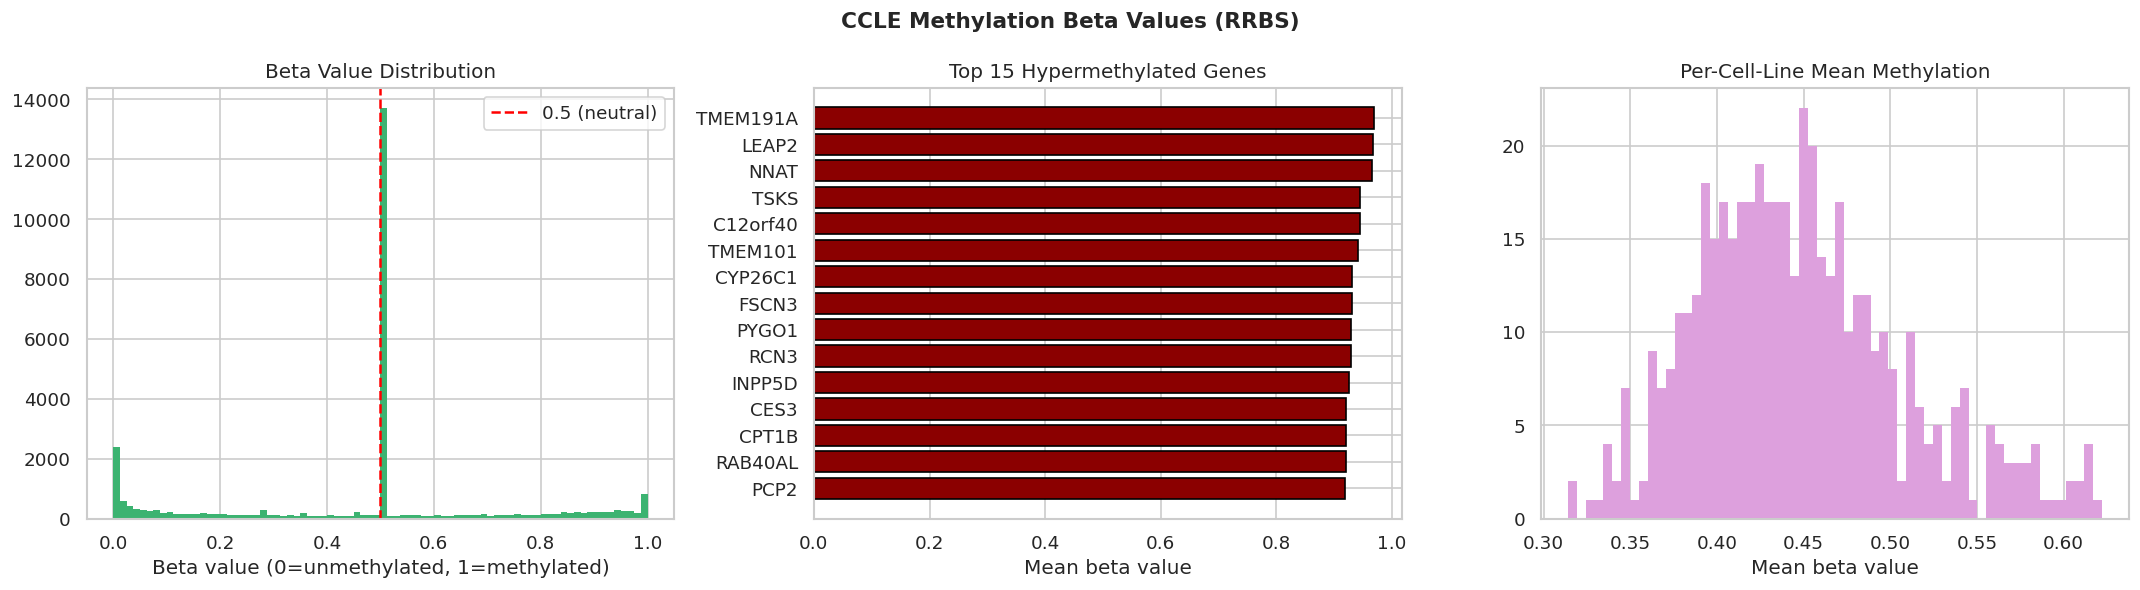

  [Methylation filtered] RAM: 11.6 MB | shape: (484, 6000)

Cell lines with Methylation: 484


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 8 — CCLE METHYLATION (RRBS)
# ═══════════════════════════════════════════════════════════════════════════
section('8. CCLE METHYLATION — LOAD, CLEAN & FILTER TO TCGA GENE SPACE')

print('Loading CCLE_RRBS_TSS_1kb_20180614.txt...')
print('Format: rows=TSS regions, cols=metadata + cell lines')
print('Values: methylation beta values (0=unmethylated, 1=fully methylated)')

meth_raw = pd.read_csv(PATH_METH, sep='\t', index_col=0)
print(f'Raw shape (rows=TSS regions, cols=metadata+cell lines): {meth_raw.shape}')
print(f'First 7 columns: {meth_raw.columns.tolist()[:7]}')

# ── Extract gene names before dropping metadata ────────────────────────────
# 'gene' column has the actual gene symbol for each TSS region
gene_col = meth_raw['gene'].values

# ── Drop all metadata columns — keep only cell line value columns ──────────
meta_cols = ['gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage']
meth_raw = meth_raw.drop(columns=meta_cols, errors='ignore')
print(f'After dropping metadata: {meth_raw.shape} (rows=TSS regions, cols=cell lines)')
print(f'Example cell line names: {meth_raw.columns.tolist()[:5]}')

# ── Convert all values to float (some may be strings) ─────────────────────
meth_raw = meth_raw.apply(pd.to_numeric, errors='coerce').astype(np.float32)

# ── Assign gene names as row index ────────────────────────────────────────
meth_raw.index = gene_col

# ── Multiple TSS regions per gene → take mean beta value per gene ─────────
before_genes = len(meth_raw)
meth_raw = meth_raw.groupby(meth_raw.index).mean()
print(f'Gene aggregation (mean per gene): {before_genes:,} TSS → {len(meth_raw):,} unique genes')

# ── Transpose: rows=cell lines, cols=genes ────────────────────────────────
meth_raw = meth_raw.T
print(f'After transpose: {meth_raw.shape} (rows=cell lines, cols=genes)')
print(f'Example cell line names: {meth_raw.index.tolist()[:5]}')

# ── Map CCLE cell line names → ModelIDs via Model.csv CCLEName column ─────
# RRBS uses names like "DMS53_LUNG", "SW1116_LARGE_INTESTINE"
model_map = pd.read_csv(PATH_MODEL, usecols=['ModelID', 'CCLEName'])
model_map = model_map.dropna(subset=['CCLEName'])
ccle_to_model = dict(zip(model_map['CCLEName'], model_map['ModelID']))

meth_raw.index = meth_raw.index.map(lambda x: ccle_to_model.get(x, None))
before = len(meth_raw)
meth_raw = meth_raw[meth_raw.index.notna()].copy()
meth_raw.index = meth_raw.index.astype(str)
print(f'\nMapped CCLE names → ModelIDs: {before:,} → {len(meth_raw):,} cell lines')

# ── Filter to cell lines with IC50 ────────────────────────────────────────
before = len(meth_raw)
meth_raw = meth_raw[meth_raw.index.isin(valid_model_ids)].copy()
print(f'Filtered to cell lines with IC50: {before:,} → {len(meth_raw):,}')

# ── Missing value handling ─────────────────────────────────────────────────
# RRBS has genuine NaN where sequencing coverage was too low
# Fill with gene-wise mean across cell lines
nan_before = meth_raw.isnull().sum().sum()
gene_means_fill = meth_raw.mean(axis=0)
meth_raw = meth_raw.fillna(gene_means_fill)
meth_raw = meth_raw.fillna(0.5)   # genes where ALL cell lines are NaN → neutral
meth_raw = meth_raw.clip(0.0, 1.0).astype(np.float32)
nan_after = meth_raw.isnull().sum().sum()
print(f'\nMissing values: {nan_before:,} → {nan_after:,} (filled with gene-wise mean, then 0.5)')

# ── Filter to TCGA gene space ──────────────────────────────────────────────
ccle_genes = set(meth_raw.columns)
tcga_genes_set = set(tcga_genes_meth)
overlap = ccle_genes & tcga_genes_set
missing_in_ccle = tcga_genes_set - ccle_genes

print(f'\nGene space alignment (Methylation):')
print(f'  TCGA selected genes:      {len(tcga_genes_meth):,}')
print(f'  CCLE available genes:     {len(ccle_genes):,}')
print(f'  Overlap:                  {len(overlap):,}')
print(f'  Missing in CCLE (→ 0.5): {len(missing_in_ccle):,} ({len(missing_in_ccle)/len(tcga_genes_meth)*100:.1f}%)')
print('  (Filling missing methylation with 0.5 = neutral/unknown)')

meth_df = meth_raw.reindex(columns=tcga_genes_meth, fill_value=0.5).astype(np.float32)
print(f'\nFinal Methylation shape: {meth_df.shape}')

# ── EDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE Methylation Beta Values (RRBS)', fontsize=13, fontweight='bold')

flat_vals = meth_df.values.flatten()[::100]  # subsample for speed

axes[0].hist(flat_vals, bins=80, color='mediumseagreen', edgecolor='none')
axes[0].set_title('Beta Value Distribution')
axes[0].set_xlabel('Beta value (0=unmethylated, 1=methylated)')
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5 (neutral)')
axes[0].legend()

gene_mean_meth = meth_df.mean(axis=0)
top_hyper = gene_mean_meth.nlargest(15)
axes[1].barh(top_hyper.index, top_hyper.values, color='darkred', edgecolor='black')
axes[1].set_title('Top 15 Hypermethylated Genes')
axes[1].set_xlabel('Mean beta value')
axes[1].invert_yaxis()

sample_mean_meth = meth_df.mean(axis=1)
axes[2].hist(sample_mean_meth, bins=60, color='plum', edgecolor='none')
axes[2].set_title('Per-Cell-Line Mean Methylation')
axes[2].set_xlabel('Mean beta value')

plt.tight_layout()
plt.show()

valid_model_ids_meth = set(meth_df.index)
mem_usage(meth_df, 'Methylation filtered')
del meth_raw, flat_vals, gene_mean_meth, sample_mean_meth, model_map, ccle_to_model
gc.collect()
print(f'\nCell lines with Methylation: {len(valid_model_ids_meth):,}')

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 9 — MASTER ALIGNMENT
#  Intersect all 4 modalities + IC50 → final aligned dataset
# ═══════════════════════════════════════════════════════════════════════════
section('9. MASTER ALIGNMENT — INTERSECT ALL MODALITIES + IC50')

# ── Find cell lines present in ALL 4 modalities ───────────────────────────
print('Cell lines per modality:')
print(f'  mRNA:      {len(valid_model_ids_mrna):,}')
print(f'  CNV:       {len(valid_model_ids_cnv):,}')
print(f'  Mutation:  {len(valid_model_ids_mut):,}')
print(f'  Meth:      {len(valid_model_ids_meth):,}')
print(f'  IC50:      {len(valid_model_ids):,}')

# Intersection of all — these are the cell lines we can actually use
# Methylation may have fewer cell lines — we handle missing meth below
common_all_4 = (valid_model_ids_mrna &
                valid_model_ids_cnv  &
                valid_model_ids_mut  &
                valid_model_ids_meth)

# Cell lines with mRNA+CNV+Mut but NO methylation → include with imputed meth
common_no_meth = (valid_model_ids_mrna &
                  valid_model_ids_cnv  &
                  valid_model_ids_mut  &
                  valid_model_ids -
                  valid_model_ids_meth)

print(f'\nCell lines with all 4 modalities:           {len(common_all_4):,}')
print(f'Cell lines missing only methylation:        {len(common_no_meth):,}')
print(f'  → Will impute missing meth with 0.5')

# Final set = all 4 + those missing only meth (imputed)
common_final = common_all_4 | common_no_meth
print(f'\nFinal usable cell lines: {len(common_final):,}')

# ── For cells missing methylation: add imputed rows (all 0.5) ─────────────
if len(common_no_meth) > 0:
    imputed_rows = pd.DataFrame(
        0.5,
        index=list(common_no_meth),
        columns=tcga_genes_meth,
        dtype=np.float32
    )
    meth_df = pd.concat([meth_df, imputed_rows])
    print(f'  Added {len(common_no_meth)} imputed methylation rows')

# ── Align all dataframes to common_final ──────────────────────────────────
cell_lines = sorted(common_final)
mrna_df = mrna_df.loc[mrna_df.index.isin(cell_lines)].loc[cell_lines]
cnv_df  = cnv_df.loc[cnv_df.index.isin(cell_lines)].loc[cell_lines]
mut_df  = mut_df.loc[mut_df.index.isin(cell_lines)].loc[cell_lines]
meth_df = meth_df.loc[meth_df.index.isin(cell_lines)].loc[cell_lines]

# ── Verify all have same row order ────────────────────────────────────────
assert (mrna_df.index == cnv_df.index).all(),  'mRNA/CNV index mismatch!'
assert (mrna_df.index == mut_df.index).all(),  'mRNA/Mut index mismatch!'
assert (mrna_df.index == meth_df.index).all(), 'mRNA/Meth index mismatch!'
print('\nAll modality indices aligned and verified ✓')

# ── Filter IC50 table to only aligned cell lines ──────────────────────────
ic50_df = ic50_df[ic50_df['ModelID'].isin(cell_lines)].copy()
print(f'IC50 rows after alignment: {len(ic50_df):,}')
print(f'Unique cell lines in IC50: {ic50_df["ModelID"].nunique():,}')
print(f'Unique drugs:              {ic50_df["DRUG_NAME"].nunique():,}')

print(f'\nFinal aligned shapes:')
print(f'  mRNA:     {mrna_df.shape}')
print(f'  CNV:      {cnv_df.shape}')
print(f'  Mutation: {mut_df.shape}')
print(f'  Meth:     {meth_df.shape}')
print(f'  IC50:     {ic50_df.shape}')

gc.collect()


══════════════════════════════════════════════════════════════════════
  9. MASTER ALIGNMENT — INTERSECT ALL MODALITIES + IC50
══════════════════════════════════════════════════════════════════════
Cell lines per modality:
  mRNA:      609
  CNV:       440
  Mutation:  776
  Meth:      484
  IC50:      786

Cell lines with all 4 modalities:           354
Cell lines missing only methylation:        84
  → Will impute missing meth with 0.5

Final usable cell lines: 438
  Added 84 imputed methylation rows

All modality indices aligned and verified ✓
IC50 rows after alignment: 12,204
Unique cell lines in IC50: 438
Unique drugs:              86

Final aligned shapes:
  mRNA:     (438, 8011)
  CNV:      (438, 3500)
  Mutation: (438, 2500)
  Meth:     (438, 6000)
  IC50:     (12204, 13)


0


══════════════════════════════════════════════════════════════════════
  10. EDA — ALIGNED DATASET
══════════════════════════════════════════════════════════════════════


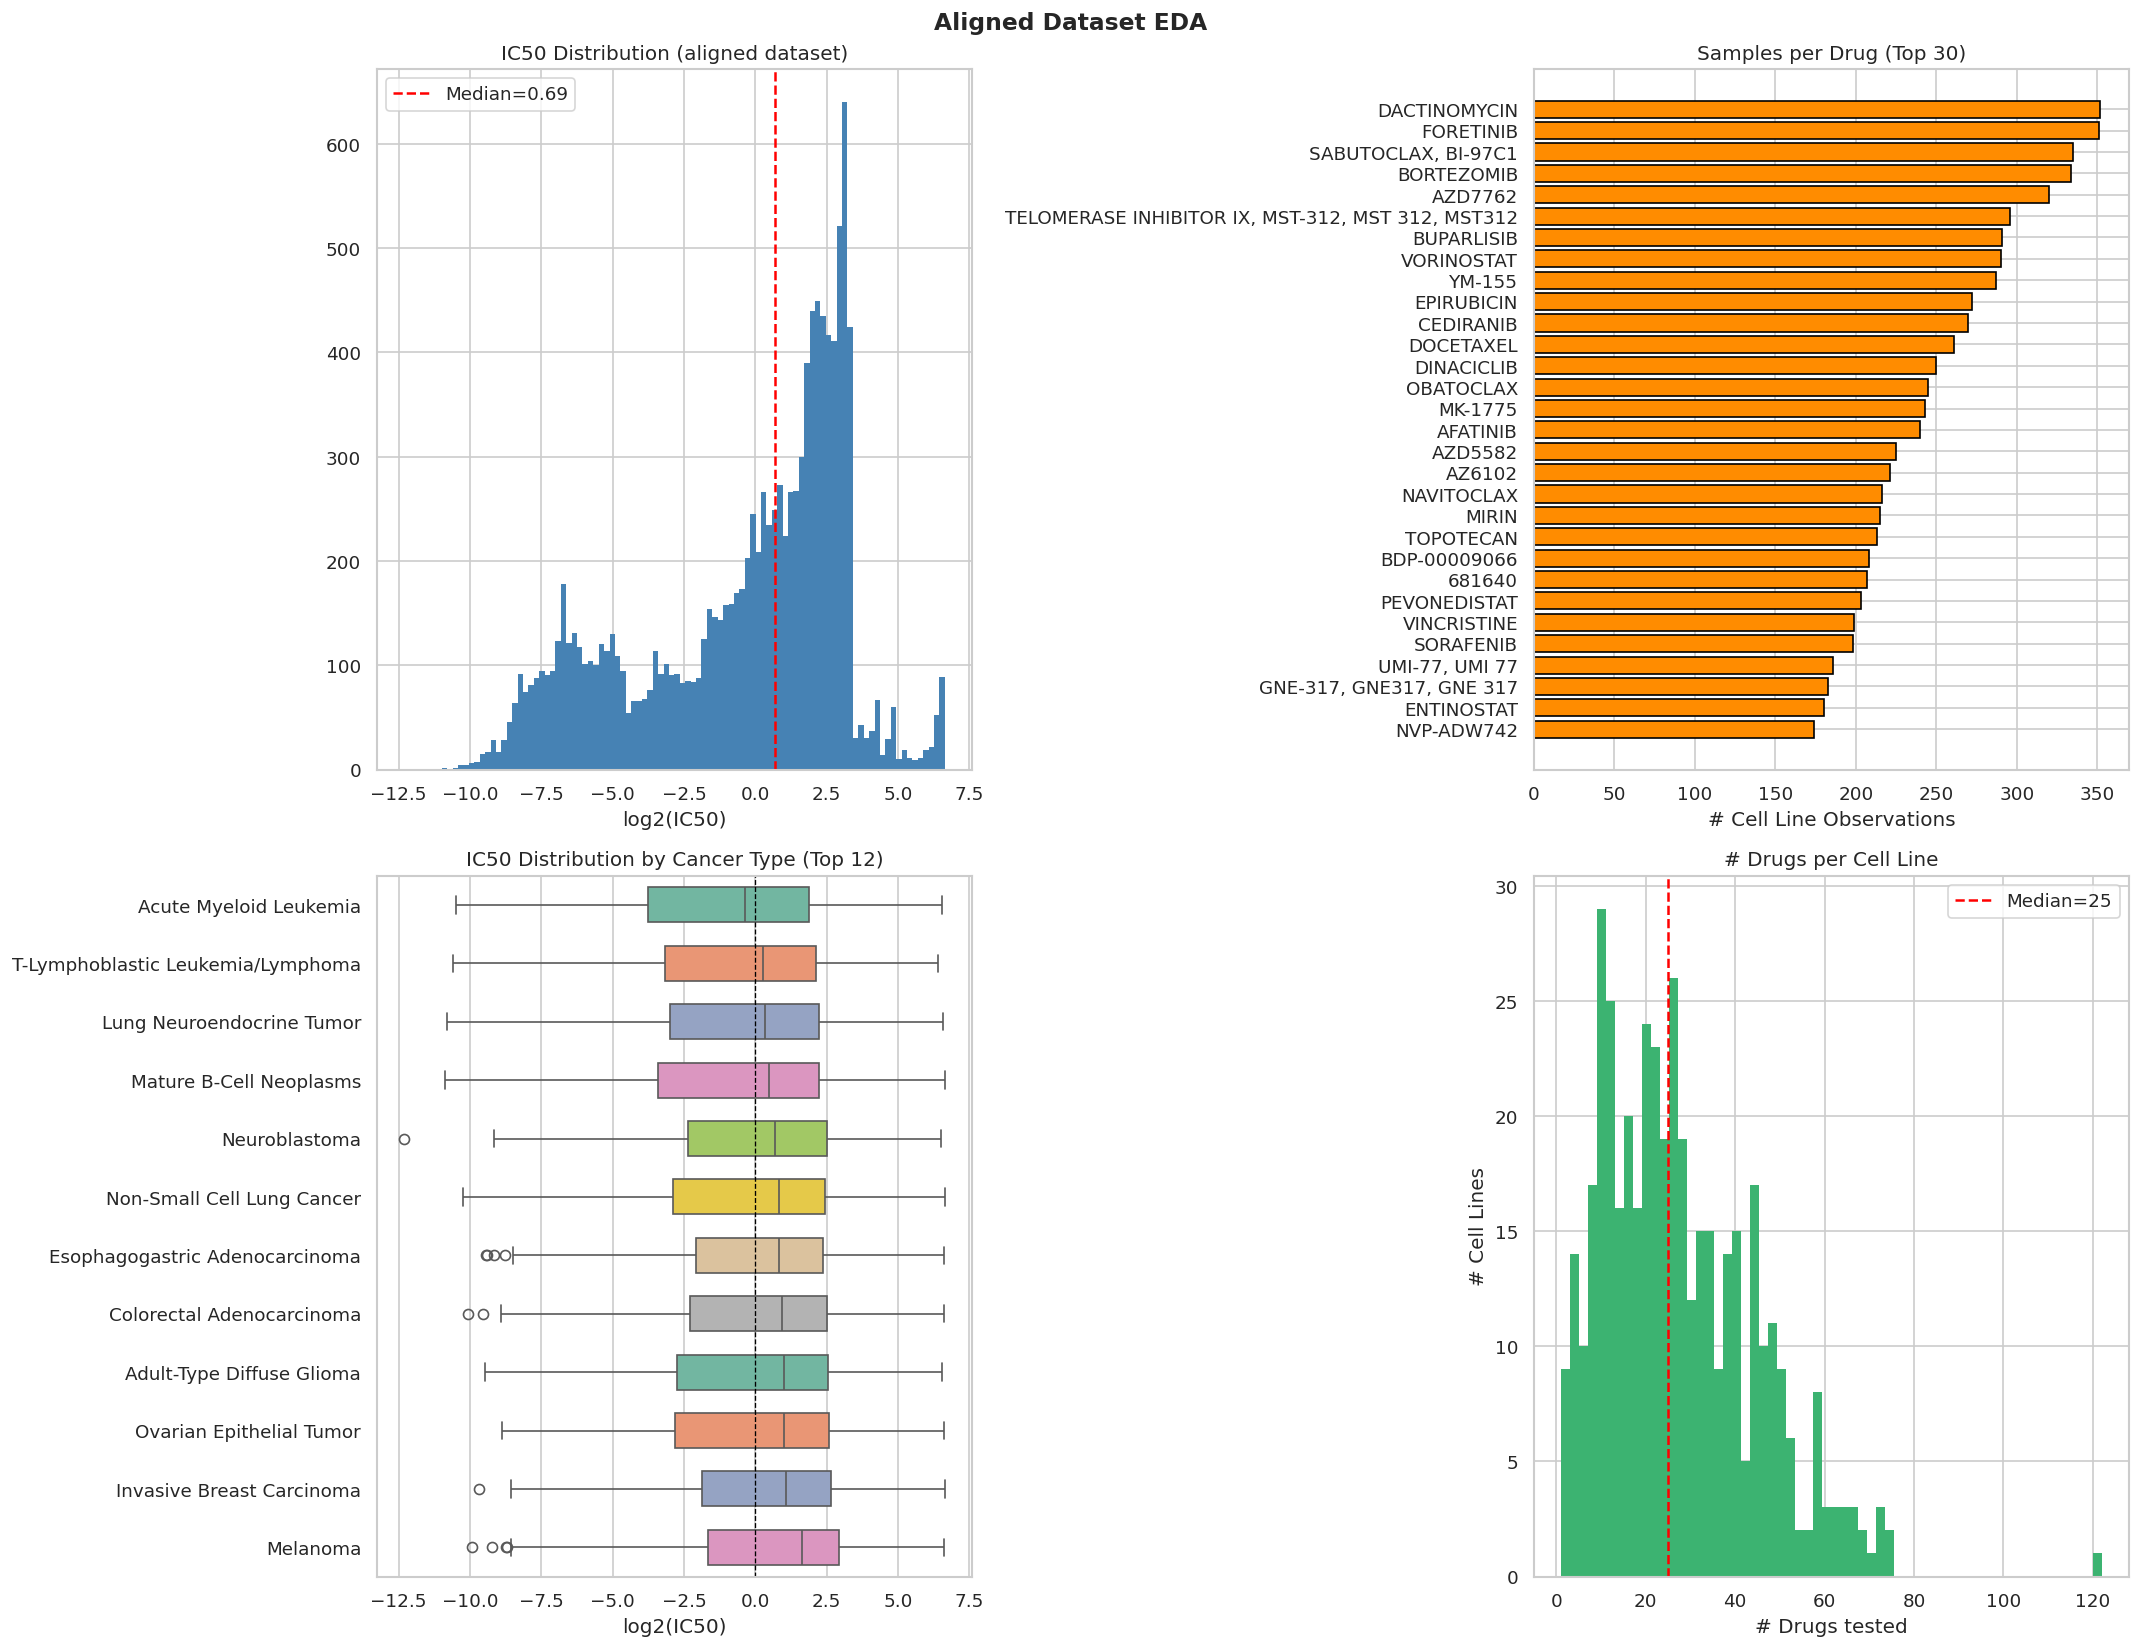


IC50 summary by DATASET:
count    12204.000
mean        -0.439
std          3.695
min        -12.314
25%         -3.008
50%          0.694
75%          2.430
max          6.642

Total training samples (cell line × drug pairs): 12,204
Unique cell lines: 438
Unique drugs:      86


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 10 — EDA ON ALIGNED DATASET
# ═══════════════════════════════════════════════════════════════════════════
section('10. EDA — ALIGNED DATASET')

# ── IC50 distribution per cancer type ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Aligned Dataset EDA', fontsize=14, fontweight='bold')

# Overall IC50 distribution
axes[0, 0].hist(ic50_df['LN_IC50'], bins=100, color='steelblue', edgecolor='none')
axes[0, 0].set_title('IC50 Distribution (aligned dataset)')
axes[0, 0].set_xlabel('log2(IC50)')
axes[0, 0].axvline(ic50_df['LN_IC50'].median(), color='red', linestyle='--',
                   label=f'Median={ic50_df["LN_IC50"].median():.2f}')
axes[0, 0].legend()

# Samples per drug
drug_counts = ic50_df['DRUG_NAME'].value_counts().head(30)
axes[0, 1].barh(drug_counts.index, drug_counts.values, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Samples per Drug (Top 30)')
axes[0, 1].set_xlabel('# Cell Line Observations')
axes[0, 1].invert_yaxis()

# IC50 per cancer type (box plot)
top_cancers = ic50_df['OncotreePrimaryDisease'].value_counts().head(12).index
ic50_sub = ic50_df[ic50_df['OncotreePrimaryDisease'].isin(top_cancers)]
ct_medians = ic50_sub.groupby('OncotreePrimaryDisease')['LN_IC50'].median().sort_values()
order = ct_medians.index.tolist()
sns.boxplot(data=ic50_sub, y='OncotreePrimaryDisease', x='LN_IC50',
            order=order, ax=axes[1, 0], palette='Set2', width=0.6)
axes[1, 0].set_title('IC50 Distribution by Cancer Type (Top 12)')
axes[1, 0].set_xlabel('log2(IC50)')
axes[1, 0].set_ylabel('')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=0.8)

# Samples per cell line (how many drugs each cell line was tested with)
cl_counts = ic50_df.groupby('ModelID').size()
axes[1, 1].hist(cl_counts, bins=60, color='mediumseagreen', edgecolor='none')
axes[1, 1].set_title('# Drugs per Cell Line')
axes[1, 1].set_xlabel('# Drugs tested')
axes[1, 1].set_ylabel('# Cell Lines')
axes[1, 1].axvline(cl_counts.median(), color='red', linestyle='--',
                   label=f'Median={cl_counts.median():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print('\nIC50 summary by DATASET:')
print(ic50_df.groupby('DATASET')['LN_IC50'].describe().round(3).to_string() if 'DATASET' in ic50_df.columns
      else ic50_df['LN_IC50'].describe().round(3).to_string())

print(f'\nTotal training samples (cell line × drug pairs): {len(ic50_df):,}')
print(f'Unique cell lines: {ic50_df["ModelID"].nunique():,}')
print(f'Unique drugs:      {ic50_df["DRUG_NAME"].nunique():,}')

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 11 — TRAIN / VAL / TEST SPLIT (AT CELL LINE LEVEL)
# ═══════════════════════════════════════════════════════════════════════════
section('11. TRAIN / VAL / TEST SPLIT — AT CELL LINE LEVEL')

# CRITICAL: split at CELL LINE level, not sample level
# Reason: if A673 is in train, ALL its drug samples are in train
# Putting same cell line in both train and test = data leakage

all_cell_lines = np.array(sorted(mrna_df.index.tolist()))
n_total = len(all_cell_lines)

# First split: train vs (val + test)
cl_train, cl_temp = train_test_split(
    all_cell_lines,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED
)

# Second split: val vs test
cl_val, cl_test = train_test_split(
    cl_temp,
    test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)),
    random_state=SEED
)

print(f'Cell line split:')
print(f'  Train: {len(cl_train):,} cell lines ({len(cl_train)/n_total*100:.1f}%)')
print(f'  Val:   {len(cl_val):,} cell lines ({len(cl_val)/n_total*100:.1f}%)')
print(f'  Test:  {len(cl_test):,} cell lines ({len(cl_test)/n_total*100:.1f}%)')

# ── Corresponding IC50 sample counts (each cell line × many drugs) ────────
n_tr_samples = ic50_df['ModelID'].isin(cl_train).sum()
n_vl_samples = ic50_df['ModelID'].isin(cl_val).sum()
n_te_samples = ic50_df['ModelID'].isin(cl_test).sum()

print(f'\nTraining samples (cell line × drug pairs):')
print(f'  Train: {n_tr_samples:,}')
print(f'  Val:   {n_vl_samples:,}')
print(f'  Test:  {n_te_samples:,}')
print(f'  Total: {n_tr_samples+n_vl_samples+n_te_samples:,}')

# ── Verify no leakage ─────────────────────────────────────────────────────
assert len(set(cl_train) & set(cl_val))  == 0, 'LEAKAGE: train/val overlap!'
assert len(set(cl_train) & set(cl_test)) == 0, 'LEAKAGE: train/test overlap!'
assert len(set(cl_val)   & set(cl_test)) == 0, 'LEAKAGE: val/test overlap!'
print('\nNo data leakage — cell line splits are clean ✓')


══════════════════════════════════════════════════════════════════════
  11. TRAIN / VAL / TEST SPLIT — AT CELL LINE LEVEL
══════════════════════════════════════════════════════════════════════
Cell line split:
  Train: 350 cell lines (79.9%)
  Val:   44 cell lines (10.0%)
  Test:  44 cell lines (10.0%)

Training samples (cell line × drug pairs):
  Train: 9,787
  Val:   1,122
  Test:  1,295
  Total: 12,204

No data leakage — cell line splits are clean ✓


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 12 — APPLY SCALERS (same logic as TCGA training)
#  Fit ONLY on train cell lines — apply to val and test
#  No variance re-selection — gene list is frozen from TCGA
# ═══════════════════════════════════════════════════════════════════════════
section('12. SCALING — FIT ON TRAIN, APPLY TO ALL')

def scale_modality(df, train_ids, scaler_type, tag):
    """
    Fit scaler on training cell lines only.
    Apply to all cell lines.
    Same logic as select_and_scale in TCGA training notebook.
    """
    X_train_rows = df.loc[df.index.isin(train_ids)].values

    if scaler_type == 'standard':
        scaler = StandardScaler()
        scaler.fit(X_train_rows)
        scaled = scaler.transform(df.values)
        print(f'  [{tag}] StandardScaler fit on {len(X_train_rows)} train cell lines')

    elif scaler_type == 'maxabs':
        scaler = MaxAbsScaler()
        scaler.fit(X_train_rows)
        scaled = scaler.transform(df.values)
        print(f'  [{tag}] MaxAbsScaler fit on {len(X_train_rows)} train cell lines')

    elif scaler_type == 'none':
        scaled = df.values.copy()
        scaler = None
        print(f'  [{tag}] No scaling (binary/bounded values)')

    else:
        raise ValueError(f'Unknown scaler_type: {scaler_type}')

    result = pd.DataFrame(scaled, index=df.index, columns=df.columns)
    return result.astype(np.float32), scaler


print('Fitting scalers on TRAINING cell lines only...')
mrna_scaled, scaler_mrna = scale_modality(mrna_df, cl_train, SCALER_TYPE['mrna'], 'mRNA')
cnv_scaled,  scaler_cnv  = scale_modality(cnv_df,  cl_train, SCALER_TYPE['cnv'],  'CNV')
mut_scaled,  scaler_mut  = scale_modality(mut_df,  cl_train, SCALER_TYPE['mut'],  'Mut')
meth_scaled, scaler_meth = scale_modality(meth_df, cl_train, SCALER_TYPE['meth'], 'Meth')

print('\nScaling verification (should be ~0 mean, ~1 std for StandardScaler):')
tr_mrna = mrna_scaled.loc[mrna_scaled.index.isin(cl_train)]
print(f'  mRNA train mean: {tr_mrna.values.mean():.4f} | std: {tr_mrna.values.std():.4f}')

del mrna_df, cnv_df, mut_df, meth_df
gc.collect()
print('\nOriginal unscaled dataframes deleted — RAM freed')


══════════════════════════════════════════════════════════════════════
  12. SCALING — FIT ON TRAIN, APPLY TO ALL
══════════════════════════════════════════════════════════════════════
Fitting scalers on TRAINING cell lines only...
  [mRNA] StandardScaler fit on 350 train cell lines
  [CNV] MaxAbsScaler fit on 350 train cell lines
  [Mut] No scaling (binary/bounded values)
  [Meth] No scaling (binary/bounded values)

Scaling verification (should be ~0 mean, ~1 std for StandardScaler):
  mRNA train mean: -0.0000 | std: 0.9594

Original unscaled dataframes deleted — RAM freed


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 13 — SAVE ALL PROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════════
section('13. SAVE PROCESSED DATA')

import joblib

# ── Save scaled omics as parquet (same format as TCGA pipeline) ───────────
print('Saving scaled omics parquets...')
mrna_scaled.to_parquet(f'{OUT_DIR}/ccle_mrna_scaled.parquet')
cnv_scaled.to_parquet(f'{OUT_DIR}/ccle_cnv_scaled.parquet')
mut_scaled.to_parquet(f'{OUT_DIR}/ccle_mut_scaled.parquet')
meth_scaled.to_parquet(f'{OUT_DIR}/ccle_meth_scaled.parquet')
print('  Saved: ccle_mrna_scaled.parquet')
print('  Saved: ccle_cnv_scaled.parquet')
print('  Saved: ccle_mut_scaled.parquet')
print('  Saved: ccle_meth_scaled.parquet')

# ── Also save as CSV ──────────────────────────────────────────────────────
print('\nAlso saving as CSV...')
mrna_scaled.to_csv(f'{OUT_DIR}/ccle_mrna_scaled.csv')
cnv_scaled.to_csv(f'{OUT_DIR}/ccle_cnv_scaled.csv')
mut_scaled.to_csv(f'{OUT_DIR}/ccle_mut_scaled.csv')
meth_scaled.to_csv(f'{OUT_DIR}/ccle_meth_scaled.csv')
ic50_df.to_csv(f'{OUT_DIR}/ccle_ic50_labels.csv', index=False)
print('  Saved all CSVs')

# ── Save IC50 label table ─────────────────────────────────────────────────
ic50_df.to_parquet(f'{OUT_DIR}/ccle_ic50_labels.parquet', index=False)
print('  Saved: ccle_ic50_labels.parquet')

# ── Save cell line splits ─────────────────────────────────────────────────
splits = {'train': cl_train.tolist(),
          'val':   cl_val.tolist(),
          'test':  cl_test.tolist()}
with open(f'{OUT_DIR}/ccle_splits.json', 'w') as f:
    json.dump(splits, f)
print('  Saved: ccle_splits.json')

# ── Save scalers ─────────────────────────────────────────────────────────
joblib.dump(scaler_mrna, f'{OUT_DIR}/scaler_mrna.pkl')
joblib.dump(scaler_cnv,  f'{OUT_DIR}/scaler_cnv.pkl')
print('  Saved: scaler_mrna.pkl, scaler_cnv.pkl')
print('  (mut and meth have no scaler — no scaling applied)')

# ── Final summary ─────────────────────────────────────────────────────────
print('\n' + '═'*70)
print('  FINAL DATASET SUMMARY')
print('═'*70)
print(f'  Cell lines:          {len(mrna_scaled):,}')
print(f'  Training samples:    {n_tr_samples:,}  (cell line × drug pairs)')
print(f'  Val samples:         {n_vl_samples:,}')
print(f'  Test samples:        {n_te_samples:,}')
print(f'  Unique drugs:        {ic50_df["DRUG_NAME"].nunique()}')
print(f'  mRNA genes:          {mrna_scaled.shape[1]:,}')
print(f'  CNV genes:           {cnv_scaled.shape[1]:,}')
print(f'  Mutation genes:      {mut_scaled.shape[1]:,}')
print(f'  Methylation genes:   {meth_scaled.shape[1]:,}')
print(f'  Total features:      {mrna_scaled.shape[1]+cnv_scaled.shape[1]+mut_scaled.shape[1]+meth_scaled.shape[1]:,}')
print('═'*70)
print('\nData processing complete. Ready for fine-tuning notebook.')


══════════════════════════════════════════════════════════════════════
  13. SAVE PROCESSED DATA
══════════════════════════════════════════════════════════════════════
Saving scaled omics parquets...
  Saved: ccle_mrna_scaled.parquet
  Saved: ccle_cnv_scaled.parquet
  Saved: ccle_mut_scaled.parquet
  Saved: ccle_meth_scaled.parquet

Also saving as CSV...
  Saved all CSVs
  Saved: ccle_ic50_labels.parquet
  Saved: ccle_splits.json
  Saved: scaler_mrna.pkl, scaler_cnv.pkl
  (mut and meth have no scaler — no scaling applied)

══════════════════════════════════════════════════════════════════════
  FINAL DATASET SUMMARY
══════════════════════════════════════════════════════════════════════
  Cell lines:          438
  Training samples:    9,787  (cell line × drug pairs)
  Val samples:         1,122
  Test samples:        1,295
  Unique drugs:        86
  mRNA genes:          8,011
  CNV genes:           3,500
  Mutation genes:      2,500
  Methylation genes:   6,000
  Total features:     